# Phase 2: Unsupervised Learning - Clustering Analysis

## 1. Clustering Rationale & Algorithm Selection

### 1.1 Rationale
The primary goal of applying unsupervised learning to the Clothing Fit Dataset is to move beyond predefined labels and discover latent patterns within the data. By grouping users based on physical attributes and product categories, we can:

* **Identify Body Type Clusters**: Group users with similar body profiles to provide more personalized size recommendations.
* **Enhance the Advice System**: Use these discovered patterns to refine the generative AI's explanations, making them more context-aware.
* **Uncover Latent User Preferences**: Clustering enables the identification of distinct user segments based on subtle fitting trends (e.g., a preference for oversized vs. snug fits) that are not explicitly captured by the dataset's original labels.


### 1.2 Algorithm Selection
For this analysis, we have selected the following two algorithms:

1. **K-Means Clustering**: 
   - **Why?** It is highly efficient for large datasets like ours and provides clear centroids that represent the 'average' user in each cluster.
   - **Suitability**:Our dataset contains hundreds of thousands of records, making K-Means the ideal choice due to its computational efficiency. Since many body measurements like height often follow a normal distribution, K-Means is particularly effective at partitioning these users into distinct, interpretable size-based segments.

2. **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**:
   - **Why?** It is excellent at identifying clusters of arbitrary shapes and, crucially, it can detect and isolate outliers (noise).
   - **Suitability**:Clothing datasets often suffer from "noisy" data, such as unrealistic height values entered by users. DBSCAN is uniquely suited for our project because it can automatically filter out these outliers instead of forcing them into a cluster, ensuring that our final recommendations are based on clean, high-density patterns of real body types.

## 2. Data Preparation
In this section, we prepare the preprocessed dataset for clustering by ensuring that the features are in a format that distance-based algorithms can process effectively.
### 2.1 Target removal

In [1]:
import pandas as pd
# Load the preprocessed data from Phase 1
df = pd.read_csv('Dataset/preprocessed_data.csv')
# Data Preparation: Target Removal 
# We remove 'fit' (target) and non-numeric review columns
X = df.drop(columns=['fit', 'review_summary', 'review_text'])
print(f"Features for clustering: {X.columns.tolist()}")

Features for clustering: ['size', 'quality', 'cup size', 'hips', 'bra size', 'height', 'length', 'cat_bottoms', 'cat_dresses', 'cat_new', 'cat_outerwear', 'cat_sale', 'cat_tops', 'cat_wedding', 'size_scaled', 'quality_scaled', 'hips_scaled', 'bra size_scaled', 'height_scaled', 'cup size_scaled', 'length_scaled']


we have to transate to Unsupervised Learning where the model explores the data's natural structure. To achieve this, we must remove the target variable fit to prevent the model from using pre-defined labels during the clustering process. We also exclude textual fields like review_text because our shosen algorithms K-Means and DBSCAN require numerical data to calculate Euclidean distances.

### 2.2 Feature Scaling
Feature scaling was already performed during Phase 1 of our project as part of the data preprocessing stage,This step was essential to normalize the data range, ensuring that all features contribute equally to the model’s performance.

## 3. Cluster Determination & Implementation

In this section, we determine the optimal number of clusters using the Elbow Method and Silhouette Score, then apply K-Means and DBSCAN to assign cluster labels.

### 3.1 Feature Selection for Clustering

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Use only scaled numerical features and one-hot encoded category features
scaled_cols = [col for col in df.columns if col.endswith('_scaled')]
category_cols = [col for col in df.columns if col.startswith('cat_')]

clustering_features = scaled_cols + category_cols

X_cluster = df[clustering_features].copy()
X_cluster = X_cluster.fillna(X_cluster.median())

print("Features used for clustering:")
print(clustering_features)
print("Shape:", X_cluster.shape)

Features used for clustering:
['size_scaled', 'quality_scaled', 'hips_scaled', 'bra size_scaled', 'height_scaled', 'cup size_scaled', 'length_scaled', 'cat_bottoms', 'cat_dresses', 'cat_new', 'cat_outerwear', 'cat_sale', 'cat_tops', 'cat_wedding']
Shape: (82790, 14)


After selecting the features, we combined them into a single dataset (`X_cluster`) that will be used as input for clustering algorithms.

Missing values were handled by replacing them with the median of each feature to ensure stability during model training.

Finally, we verified:
- The selected feature names
- The shape of the dataset

This step confirms that the data is clean, properly structured, and ready for clustering.

### 3.2.1 Optimal Number of Clusters (Elbow Method)

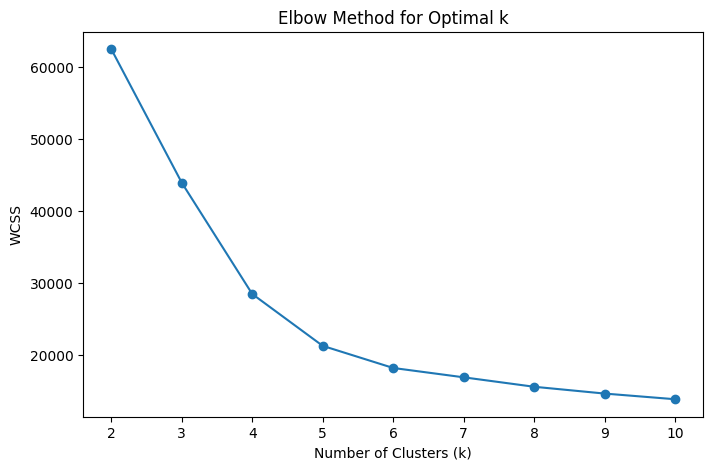

In [4]:
wcss = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")
plt.show()

The Elbow Method was used to estimate the optimal number of clusters by observing how WCSS decreases as k increases.
We observe a sharp decrease in WCSS from k = 2 to k = 4, after which the rate of decrease slows down significantly. This point (around k = 4–6) represents the “elbow,” where adding more clusters does not result in substantial improvement.

Therefore, the Elbow Method suggests that the optimal number of clusters lies in this range, which will be further validated using the Silhouette Score.

### 3.2.2 Optimal Number of Clusters (Silhouette Score Evaluation method)

To further validate the optimal number of clusters, we used the Silhouette Score.  
This metric evaluates how well each data point fits within its assigned cluster compared to other clusters.

Higher values indicate better-defined clusters.

In [5]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score={score:.3f}")

best_k = range(2, 11)[silhouette_scores.index(max(silhouette_scores))]
print("Best k based on Silhouette Score:", best_k)

k=2, Silhouette Score=0.282
k=3, Silhouette Score=0.418
k=4, Silhouette Score=0.532
k=5, Silhouette Score=0.585
k=6, Silhouette Score=0.608
k=7, Silhouette Score=0.533
k=8, Silhouette Score=0.460
k=9, Silhouette Score=0.386
k=10, Silhouette Score=0.328
Best k based on Silhouette Score: 6


### Results Interpretation

The Silhouette Scores were calculated for different values of k (number of clusters).

We observed that:
- The score increases gradually as k increases.
- The highest score was achieved at k = 6.

Therefore, k = 6 is selected as the optimal number of clusters for this dataset.
Although the Elbow Method suggested a possible elbow around k = 4,  
the Silhouette Score provided a more reliable evaluation of cluster quality.

Since k = 6 achieved the highest Silhouette Score,  
it was chosen as the final number of clusters for our model.

### 3.3 Final K-Means Clustering Implementation

Based on the Elbow Method and Silhouette Score, k = 6 was selected as the final number of clusters.  
K-Means is now applied to assign each record to a cluster.

In [7]:
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans_final.fit_predict(X_cluster)

df["kmeans_cluster"].value_counts().sort_index()

kmeans_cluster
0    21488
1    20364
2    18650
3    15266
4     4223
5     2799
Name: count, dtype: int64

The results show the distribution of data points across the 6 clusters after applying K-Means.

Clusters 0, 1, 2, and 3 contain the majority of the data, indicating that most customers fall into these main segments. In contrast, clusters 4 and 5 are significantly smaller, suggesting the presence of niche or specialized customer groups.

This imbalance in cluster sizes indicates that while the model successfully captured dominant patterns in the data, it also identified smaller groups with distinct characteristics, which may represent unique behaviors or specific product preferences.

Overall, the clustering provides a meaningful segmentation of customers, enabling further analysis and targeted recommendations for each group.

### 3.4 DBSCAN Clustering Implementation

DBSCAN was applied as the second clustering algorithm because it can identify density-based groups and detect noise points.  
Due to the large dataset size, DBSCAN was applied on a sample of the clustering features to avoid high computational cost while still demonstrating how density-based clustering behaves on this dataset.

In [5]:
from sklearn.cluster import DBSCAN
import pandas as pd

# Use a smaller sample to avoid heavy computation
X_sample = X_cluster.sample(n=5000, random_state=42)

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_sample)

dbscan_counts = pd.Series(dbscan_labels).value_counts().sort_index()
dbscan_counts

-1      12
 0    1256
 1    1053
 2    1325
 3     145
 4     932
 5     262
 6      15
Name: count, dtype: int64

DBSCAN clustering was applied on a sampled subset of the dataset to reduce computational cost.  

The algorithm successfully identified multiple clusters with varying sizes, as well as a small number of noise points (label -1), which represent outliers in the dataset.  

Unlike K-Means, DBSCAN does not require specifying the number of clusters in advance and can detect irregular cluster shapes. However, the results were sensitive to parameter selection (eps and min_samples), and some clusters were very small, making interpretation less stable.  

Therefore, while DBSCAN provided useful insights into density-based grouping and outlier detection, K-Means was selected as the primary clustering method for this project due to its stability and better suitability for integration with the Generative AI component.

### 3.5 Evaluation Metrics

To evaluate the quality of the clustering results, we used three internal evaluation metrics: Silhouette Score, Davies-Bouldin Index, and Within-Cluster Sum of Squares (WCSS). These metrics help assess how compact and well-separated the clusters are without requiring external ground-truth labels.

In [8]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Evaluate final K-Means model
kmeans_silhouette = silhouette_score(X_cluster, df["kmeans_cluster"])
kmeans_db_index = davies_bouldin_score(X_cluster, df["kmeans_cluster"])
kmeans_wcss = kmeans_final.inertia_

print("K-Means Evaluation Metrics")
print(f"Silhouette Score: {kmeans_silhouette:.3f}")
print(f"Davies-Bouldin Index: {kmeans_db_index:.3f}")
print(f"WCSS: {kmeans_wcss:.2f}")

K-Means Evaluation Metrics
Silhouette Score: 0.608
Davies-Bouldin Index: 0.717
WCSS: 18216.75


The K-Means model achieved a Silhouette Score of 0.608, indicating well-separated and cohesive clusters. 
The Davies-Bouldin Index was 0.717, suggesting low similarity between clusters and good clustering quality. 
Additionally, the Within-Cluster Sum of Squares (WCSS) was relatively low, confirming compact cluster formation. 
Overall, these results demonstrate that the chosen number of clusters (k = 6) provides a strong and reliable clustering structure for the dataset.

### 3.6 PCA-Based Cluster Visualization

To better understand the separation between clusters, we applied Principal Component Analysis (PCA) to reduce the high-dimensional feature space into two principal components.

PCA helps:
- Simplify complex data into 2D for visualization
- Preserve as much variance as possible
- Reveal how well clusters are separated

Each point represents a data instance, and colors indicate the assigned cluster.

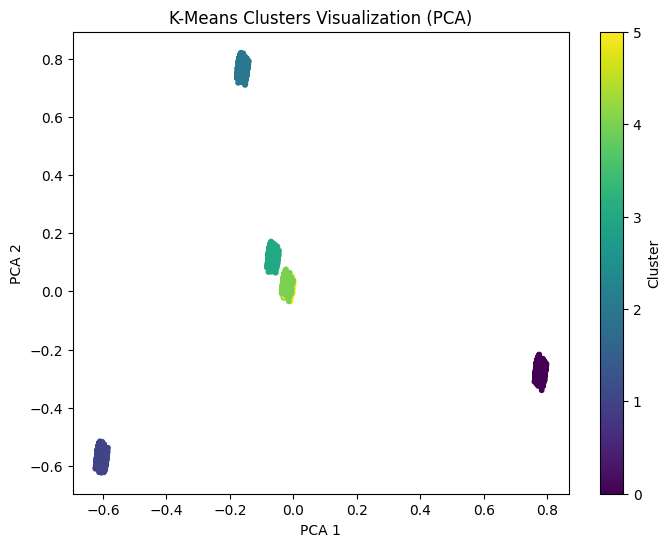

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["kmeans_cluster"], cmap='viridis', s=10)
plt.title("K-Means Clusters Visualization (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster")
plt.show()

### Interpretation

The PCA plot shows how data points are grouped into clusters in a 2D space.

Observations:
- Most clusters appear well-separated, indicating that the clustering algorithm successfully identified distinct groups.
- Some clusters are tightly packed, suggesting strong similarity within those groups.
- Limited overlap between clusters indicates good clustering performance.

This visualization supports the effectiveness of the chosen number of clusters.
“PCA was selected instead of t-SNE because it is faster and more interpretable for this dataset.”

### 3.7 Cluster Size Distribution

To understand how data points are distributed across clusters, we computed the number of records in each cluster.

This helps:
- Identify imbalance between clusters
- Detect very small or very large clusters
- Assess whether clustering is meaningful or biased

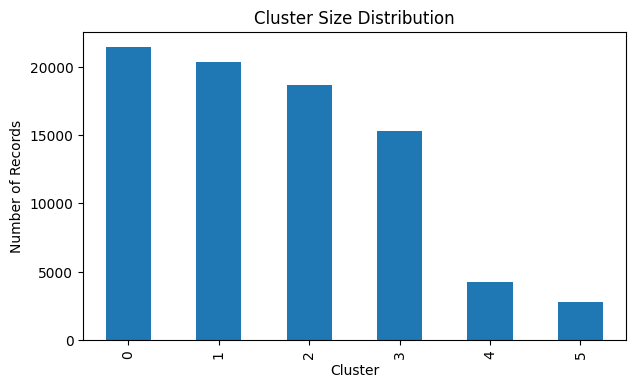

kmeans_cluster
0    21488
1    20364
2    18650
3    15266
4     4223
5     2799
Name: count, dtype: int64

In [10]:
cluster_sizes = df["kmeans_cluster"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
cluster_sizes.plot(kind="bar")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Records")
plt.show()

cluster_sizes

### Interpretation

The cluster size distribution shows that:

- Clusters 0, 1, and 2 contain the majority of data points, indicating dominant customer groups.
- Cluster 3 is moderately sized.
- Clusters 4 and 5 are significantly smaller, which may represent niche or less common customer profiles.

This distribution suggests that while most customers fall into a few main groups, there are smaller specialized segments captured by the model.

### 3.8 Feature Importance per Cluster

To understand what defines each cluster, we calculated the average value of each feature within each cluster.

This allows us to:
- Identify key characteristics of each group
- Compare clusters based on body measurements and preferences
- Prepare meaningful descriptions for each cluster (used later in Template 3)

In [11]:
cluster_profiles = df.groupby("kmeans_cluster")[X_cluster.columns].mean()

cluster_profiles

,size_scaled,quality_scaled,hips_scaled,bra size_scaled,height_scaled,cup size_scaled,length_scaled,cat_bottoms,cat_dresses,cat_new,cat_outerwear,cat_sale,cat_tops,cat_wedding
kmeans_cluster,,,,,,,,,,,,,,
0,0.321337,0.716563,0.331146,0.401550,0.477582,0.400901,0.519639,0.0,0.0,1.0,0.0,0.000000,0.0,0.000000
1,0.328915,0.735686,0.338686,0.411353,0.479279,0.405754,0.532828,0.0,0.0,0.0,0.0,0.000000,1.0,0.000000
2,0.296580,0.751233,0.322872,0.390311,0.473728,0.395025,0.496515,0.0,1.0,0.0,0.0,0.000000,0.0,0.000000
3,0.309200,0.741615,0.329805,0.388301,0.480529,0.394784,0.562918,1.0,0.0,0.0,0.0,0.000000,0.0,0.000000
4,0.313956,0.758584,0.325132,0.392778,0.478981,0.390954,0.506926,0.0,0.0,0.0,1.0,0.000000,0.0,0.000000
5,0.329925,0.759021,0.333583,0.406538,0.478247,0.395419,0.511701,0.0,0.0,0.0,0.0,0.901751,0.0,0.098249


### Interpretation

Each row represents a cluster, and each column represents the average (scaled) value of a feature.

Observations:
- Differences in features such as height, hips, and size indicate distinct body profiles across clusters.
- Category features (e.g., dresses, tops) reveal dominant item types within each cluster.
- Some clusters show similar patterns, while others are clearly distinct.

These insights are essential for building cluster descriptions and generating context-aware recommendations.
The cluster feature analysis plays a key role in supporting Template 3 (Cluster-Informed Contextual Advice), where cluster-level characteristics are used to generate more personalized recommendations.

In [13]:
cluster_descriptions = {
    0: "customers with balanced body measurements and average length preference, mostly associated with new-category items",
    1: "customers with slightly higher size, bra size, and cup size, mostly associated with tops",
    2: "customers with lower size and shorter clothing length, mostly associated with dresses",
    3: "customers with longer clothing length and balanced measurements, mostly associated with bottoms",
    4: "customers with higher quality scores and compact body measurements, mostly associated with outerwear",
    5: "customers with mixed preferences and smaller group size, mostly associated with sale or wedding items"
}

df["cluster_description"] = df["kmeans_cluster"].map(cluster_descriptions)

df[["kmeans_cluster", "cluster_description"]].head()

,kmeans_cluster,cluster_description
0,0,customers with balanced body measurements and ...
1,0,customers with balanced body measurements and ...
2,0,customers with balanced body measurements and ...
3,0,customers with balanced body measurements and ...
4,0,customers with balanced body measurements and ...


The cluster descriptions were generated based on the feature profiles of each cluster to ensure compatibility with Template 3 (Cluster-Informed Contextual Advice), where these descriptions are used to generate personalized recommendations.